# Thomas S Zhang DSBI HW1 

# Data Sourcing

To address the business problem, I acquired three publicly available datasets from external sources. First, I used a Netflix TV Shows and Movies dataset, which contains title-level metadata such as title, type, release year, runtime, age certification, IMDb score, and IMDb vote count. Second, I used Netflix’s public What We Watched engagement report, which includes title-level watch-time variables such as Hours Viewed, along with release date and global availability. Third, I used Google Trends data for major streaming-related search terms to capture public interest over time in Netflix and competing platforms.

These datasets were selected because each contributes a different layer of evidence for the business problem. The Netflix title dataset provides the main explanatory variables describing the content itself, the engagement report provides a stronger performance outcome through watch time, and Google Trends provides market-level time-series context. All three datasets were obtained from publicly available sources, making them appropriate for a reproducible notebook focused on data sourcing, cleaning, and exploratory analysis.

In [6]:
import pandas as pd

# Load the two files
titles_df = pd.read_csv("Netflix TV Shows and Movies.csv")
watched_df = pd.read_csv("What_We_Watched_A_Netflix_Engagement_Report_2023Jan-Jun.csv")

# Quick check
print("Titles dataset shape:", titles_df.shape)
print("What We Watched dataset shape:", watched_df.shape)

print("\nTitles dataset columns:")
print(titles_df.columns.tolist())

print("\nWhat We Watched dataset columns:")
print(watched_df.columns.tolist())

print("\nTitles dataset preview:")
print(titles_df.head())

print("\nWhat We Watched dataset preview:")
print(watched_df.head())

Titles dataset shape: (5283, 11)
What We Watched dataset shape: (18219, 6)

Titles dataset columns:
['index', 'id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'imdb_id', 'imdb_score', 'imdb_votes']

What We Watched dataset columns:
['Unnamed: 0', 'Title', 'Available Globally?', 'Release Date', 'Hours Viewed', 'Unnamed: 5']

Titles dataset preview:
   index        id                            title   type  \
0      0   tm84618                      Taxi Driver  MOVIE   
1      1  tm127384  Monty Python and the Holy Grail  MOVIE   
2      2   tm70993                    Life of Brian  MOVIE   
3      3  tm190788                     The Exorcist  MOVIE   
4      4   ts22164     Monty Python's Flying Circus   SHOW   

                                         description  release_year  \
0  A mentally unstable Vietnam War veteran works ...          1976   
1  King Arthur, accompanied by his squire, recrui...          1975   
2  Brian Cohen is an average y

# Data Cleaning

In [13]:
##clean first 5 rows of empty info for 2nd dataset
watched_df = watched_df.iloc[5:].reset_index(drop=True)
watched_df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,NaN,Fake Profile: Season 1 // Perfil falso: Tempor...,No,2023-05-31,"206,500,000",NaN
1,NaN,Vikings: Valhalla: Season 2,Yes,2023-01-12,"205,500,000",NaN
2,NaN,Extraction 2,Yes,2023-06-16,"201,800,000",NaN
3,NaN,"XO, Kitty: Season 1",Yes,2023-05-18,"200,700,000",NaN
4,NaN,Doctor Cha: Limited Series // 닥터 차정숙: 리미티드 시리즈,Yes,2023-04-15,"194,700,000",NaN


In [26]:
clean_watchdf = watched_df.drop(columns=["Unnamed: 0", "Unnamed: 5"]).copy()

clean_watchdf.columns = ["Title", "Available_Globally", "Release_Date", "Hours_Viewed"]

clean_watchdf.to_csv("clean_watchdf.csv", index=False)

print(clean_watchdf.head())
print(clean_watchdf.columns)
clean_watchdf.head()

## Optional: clean_watchdf.to_csv("clean_watchdf.csv", index=False)

# Check missing values before merging
print("Missing values in titles_df:")
print(titles_df.isna().sum())

print("\nMissing values in clean_watchdf:")
print(clean_watchdf.isna().sum())
# Check duplicate rows
print("Duplicate rows in titles_df:", titles_df.duplicated().sum())
print("Duplicate rows in clean_watchdf:", clean_watchdf.duplicated().sum())
# Make sure numeric columns are actually numeric
titles_df["imdb_score"] = pd.to_numeric(titles_df["imdb_score"], errors="coerce")
titles_df["imdb_votes"] = pd.to_numeric(titles_df["imdb_votes"], errors="coerce")
titles_df["runtime"] = pd.to_numeric(titles_df["runtime"], errors="coerce")

                                               Title Available_Globally  \
0  Fake Profile: Season 1 // Perfil falso: Tempor...                 No   
1                        Vikings: Valhalla: Season 2                Yes   
2                                       Extraction 2                Yes   
3                                XO, Kitty: Season 1                Yes   
4     Doctor Cha: Limited Series // 닥터 차정숙: 리미티드 시리즈                Yes   

  Release_Date Hours_Viewed  
0   2023-05-31  206,500,000  
1   2023-01-12  205,500,000  
2   2023-06-16  201,800,000  
3   2023-05-18  200,700,000  
4   2023-04-15  194,700,000  
Index(['Title', 'Available_Globally', 'Release_Date', 'Hours_Viewed'], dtype='object')
Missing values in titles_df:
index                   0
id                      0
title                   0
type                    0
description             5
release_year            0
age_certification    2285
runtime                 0
imdb_id                 0
imdb_score         


Before merging the datasets, I checked for missing values, duplicate rows, and inconsistent data types. For the Netflix engagement dataset, I removed the first five blank rows, dropped the unnecessary `Unnamed: 0` and `Unnamed: 5` columns, and renamed the remaining columns for clarity. I also converted key numeric fields in the Netflix title dataset, including `imdb_score`, `imdb_votes`, and `runtime`, into proper numeric format so they could be used in subsequent analysis. Additional title standardization and `Hours_Viewed` conversion were completed during the merge-preparation step.

## Connect "Netflix TV Shows and Movies dataset" with "What We Watched engagement report"

In [37]:
import pandas as pd
import numpy as np
import re

# ----------------------------
# 1) Load the two CSV files
# ----------------------------
titles_df = pd.read_csv("Netflix TV Shows and Movies.csv")
watch_df = pd.read_csv("clean_watchdf.csv")

# ----------------------------
# 2) Standardize title text so the two files can match
# Why this is needed:
# - watch_df has titles like "XO, Kitty: Season 1"
# - titles_df may only have "XO, Kitty"
# - some watch_df titles also include translated titles after " // "
# ----------------------------
def clean_title(title):
    if pd.isna(title):
        return np.nan
    
    title = str(title).strip().lower()
    
    # Keep only the first title before translated/alternate titles
    title = title.split(" // ")[0]
    
    # Remove trailing season labels like ": Season 1", ": Season 2"
    title = re.sub(r":\s*season\s*\d+\s*$", "", title, flags=re.IGNORECASE)
    
    # Remove trailing labels like ": Limited Series"
    title = re.sub(r":\s*limited\s+series\s*$", "", title, flags=re.IGNORECASE)
    
    # Clean extra spaces
    title = re.sub(r"\s+", " ", title).strip()
    
    return title

# Apply cleaning to both files
titles_df["match_title"] = titles_df["title"].apply(clean_title)
watch_df["match_title"] = watch_df["Title"].apply(clean_title)
titles_df["imdb_score"] = pd.to_numeric(titles_df["imdb_score"], errors="coerce")
titles_df["imdb_votes"] = pd.to_numeric(titles_df["imdb_votes"], errors="coerce")
titles_df["runtime"] = pd.to_numeric(titles_df["runtime"], errors="coerce")

# ----------------------------
# 3) Convert Hours_Viewed to numeric
# clean_watchdf stores it like "206,500,000"
# ----------------------------
watch_df["Hours_Viewed"] = (
    watch_df["Hours_Viewed"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

watch_df["Hours_Viewed"] = pd.to_numeric(watch_df["Hours_Viewed"], errors="coerce")

# ----------------------------
# 4) Aggregate watch-time data by cleaned title
# Why:
# - "Bridgerton: Season 1" and "Bridgerton: Season 2"
#   both become "bridgerton"
# - summing gives total watch hours for that title key
# ----------------------------
watch_agg = (
    watch_df.groupby("match_title", as_index=False)
    .agg(
        Hours_Viewed=("Hours_Viewed", "sum"),
        Available_Globally=("Available_Globally", "first"),
        Release_Date=("Release_Date", "first"),
        Watch_Title=("Title", "first"),
        watch_rows=("Title", "size")
    )
)

# ----------------------------
# 5) Merge the two datasets
# Left join keeps all titles from the Netflix TV Shows and Movies file
# ----------------------------
merged_df = titles_df.merge(
    watch_agg,
    on="match_title",
    how="left"
)

# ----------------------------
# 6) Check whether the merge worked
# ----------------------------
matched_rows = merged_df["Hours_Viewed"].notna().sum()
total_rows = len(merged_df)

print(f"Matched rows: {matched_rows} out of {total_rows}")
print(f"Match rate: {matched_rows / total_rows:.2%}")

# Preview useful columns
print(
    merged_df[
        [
            "title",
            "type",
            "release_year",
            "runtime",
            "imdb_score",
            "imdb_votes",
            "Hours_Viewed"
        ]
    ].head(10)
)


# ----------------------------
# 7) Optional: save merged result
# ----------------------------
#merged_df.to_csv("merged_netflix_watchdata.csv", index=False)

Matched rows: 3674 out of 5283
Match rate: 69.54%
                             title   type  release_year  runtime  imdb_score  \
0                      Taxi Driver  MOVIE          1976      113         8.3   
1  Monty Python and the Holy Grail  MOVIE          1975       91         8.2   
2                    Life of Brian  MOVIE          1979       94         8.0   
3                     The Exorcist  MOVIE          1973      133         8.1   
4     Monty Python's Flying Circus   SHOW          1969       30         8.8   
5                      Dirty Harry  MOVIE          1971      102         7.7   
6                     My Fair Lady  MOVIE          1964      170         7.8   
7                  The Blue Lagoon  MOVIE          1980      104         5.8   
8                 Bonnie and Clyde  MOVIE          1967      110         7.7   
9                The Professionals  MOVIE          1966      117         7.3   

   imdb_votes  Hours_Viewed  
0    795222.0    24800000.0  
1    5308

In [27]:
merged_df.head(5)

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes,match_title,Hours_Viewed,Available_Globally,Release_Date,Watch_Title,watch_rows
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0,taxi driver,24800000.0,No,None,Taxi Driver // 모범택시,1.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0,monty python and the holy grail,2400000.0,Yes,None,Monty Python and the Holy Grail,1.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0,life of brian,NaN,NaN,NaN,NaN,NaN
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0,the exorcist,NaN,NaN,NaN,NaN,NaN
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0,monty python's flying circus,NaN,NaN,NaN,NaN,NaN


In [38]:
final_df = merged_df.dropna(subset=["Hours_Viewed"]).copy().reset_index(drop=True)
final_df.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes,match_title,Hours_Viewed,Available_Globally,Release_Date,Watch_Title,watch_rows
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0,taxi driver,24800000.0,No,None,Taxi Driver // 모범택시,1.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0,monty python and the holy grail,2400000.0,Yes,None,Monty Python and the Holy Grail,1.0
2,7,tm98978,The Blue Lagoon,MOVIE,Two small children and a ship's cook survive a...,1980,R,104,tt0080453,5.8,69053.0,the blue lagoon,4900000.0,No,None,The Blue Lagoon,1.0
3,10,tm44204,The Guns of Navarone,MOVIE,A team of allied saboteurs are assigned an imp...,1961,NaN,158,tt0054953,7.5,50150.0,the guns of navarone,500000.0,No,None,The Guns of Navarone,1.0
4,12,tm69997,Richard Pryor: Live in Concert,MOVIE,"Richard Pryor delivers monologues on race, sex...",1979,R,78,tt0079807,8.1,5141.0,richard pryor: live in concert,900000.0,Yes,None,Richard Pryor: Live in Concert,1.0


After merging the datasets, **3674 of 5283 rows matched**, resulting in a **69.54% match rate**. Titles that did not find a match in the engagement report produced missing `Hours_Viewed` values. To ensure that watch-time analyses used only valid engagement observations, I created `final_df` by excluding rows with missing `Hours_Viewed`.

# Load the google trends dataset

In [39]:
trends_df = pd.read_csv("time_series_US_20210419-1411_20260419-1411.csv")

print(trends_df.shape)
print(trends_df.columns)
print(trends_df.head())
print(trends_df.isna().sum())
# No missing values were found in the Google Trends dataset.

(61, 6)
Index(['Time', 'Disney+', 'HBO Max', 'amazon prime video', 'Netflix', 'Hulu'], dtype='object')
         Time  Disney+  HBO Max  amazon prime video  Netflix  Hulu
0  2021-04-01       16       18                   4       66    22
1  2021-05-01       15       16                   4       69    22
2  2021-06-01       19       17                   4       64    23
3  2021-07-01       20       15                   3       69    21
4  2021-08-01       15       13                   3       65    21
Time                  0
Disney+               0
HBO Max               0
amazon prime video    0
Netflix               0
Hulu                  0
dtype: int64


# Exploratory Data Analysis

## 1. histogram of Hours_Viewed

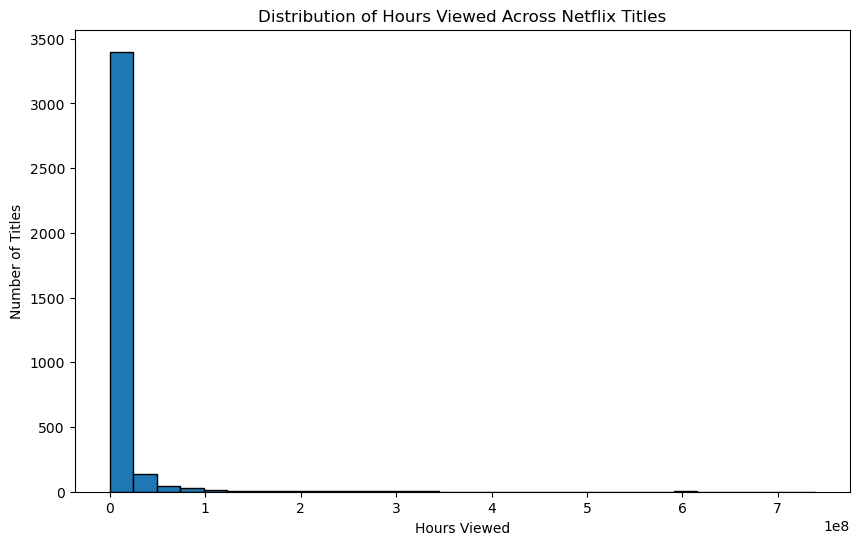

In [40]:
import matplotlib.pyplot as plt

# Histogram of Hours_Viewed
# This shows how watch time is distributed across matched Netflix titles.
# It helps us see whether engagement is concentrated in a small number of titles
# or spread more evenly across the catalog.

plt.figure(figsize=(10, 6))
plt.hist(final_df["Hours_Viewed"], bins=30, edgecolor="black")
plt.title("Distribution of Hours Viewed Across Netflix Titles")
plt.xlabel("Hours Viewed")
plt.ylabel("Number of Titles")
plt.show()

The histogram of `Hours_Viewed` shows a strongly right-skewed distribution, meaning that most Netflix titles receive relatively low to moderate watch time while a small number of titles generate exceptionally high viewing totals. This suggests that audience engagement is concentrated in a limited set of breakout titles, which implies that a small number of high-performing titles may play a disproportionately important role in Netflix’s overall viewer engagement and content strategy.

## 2: histogram of imdb_score

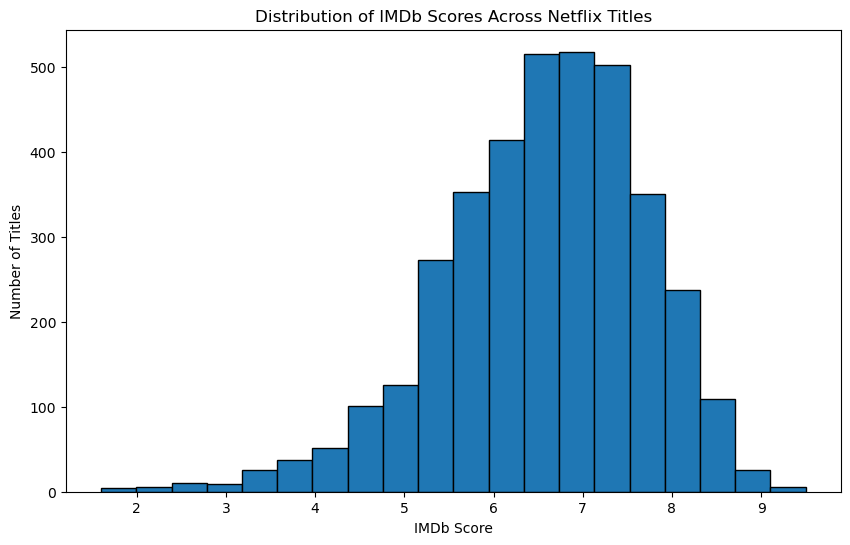

In [41]:
import matplotlib.pyplot as plt

# Histogram of IMDb scores
# This shows how audience ratings are distributed across the matched Netflix titles.
# It helps us see whether most titles are clustered around average ratings
# or whether scores are spread widely across the catalog.

plt.figure(figsize=(10, 6))
plt.hist(final_df["imdb_score"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of IMDb Scores Across Netflix Titles")
plt.xlabel("IMDb Score")
plt.ylabel("Number of Titles")
plt.show()

The histogram of `imdb_score` shows that most matched Netflix titles are rated in the mid-to-upper range, with the highest concentration roughly between 6 and 8. This indicates that audience ratings are generally more stable and less extreme than watch-time outcomes, suggesting that perceived quality across the catalog is relatively consistent even though actual engagement may vary much more widely from one title to another.

## 3: boxplot of imdb_score by type.

<Figure size 1000x600 with 0 Axes>

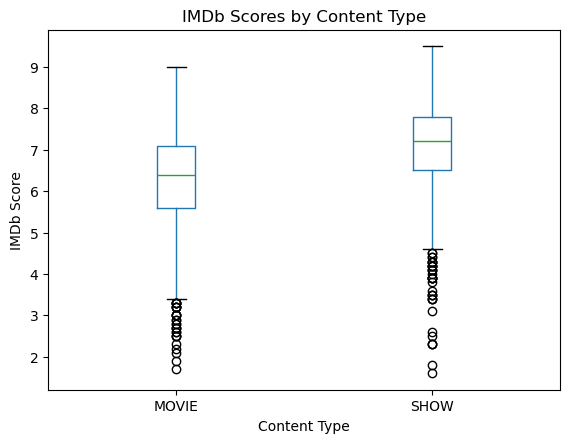

In [42]:
import matplotlib.pyplot as plt

# Boxplot of IMDb score by content type
# This compares the distribution of audience ratings for Movies vs TV Shows.
# It helps show whether one format tends to receive higher ratings
# and whether one category has more variability than the other.

plt.figure(figsize=(10, 6))
final_df.boxplot(column="imdb_score", by="type", grid=False)

plt.title("IMDb Scores by Content Type")
plt.suptitle("")  # removes the automatic pandas subtitle
plt.xlabel("Content Type")
plt.ylabel("IMDb Score")

plt.show()

The boxplot of `imdb_score` by `type` shows that TV shows generally have higher IMDb ratings than movies. The median score for shows is clearly above the median for movies, and the overall distribution for shows is shifted upward. This suggests that, in the matched dataset, show-format content tends to receive stronger audience reception than movie-format content, which may have important implications for Netflix’s content strategy.

## 4: boxplot of Hours_Viewed by type.

<Figure size 1000x600 with 0 Axes>

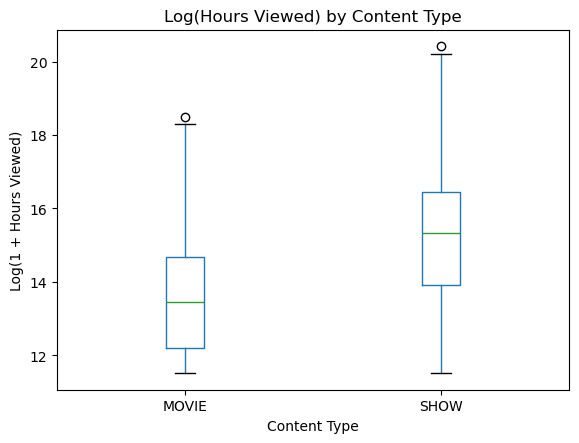

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Boxplot of log-transformed Hours_Viewed by content type
# log1p reduces the effect of extreme outliers and makes comparisons easier.

plot_df = final_df.copy()
plot_df["log_Hours_Viewed"] = np.log1p(plot_df["Hours_Viewed"])

plt.figure(figsize=(10, 6))
plot_df.boxplot(column="log_Hours_Viewed", by="type", grid=False)

plt.title("Log(Hours Viewed) by Content Type")
plt.suptitle("")
plt.xlabel("Content Type")
plt.ylabel("Log(1 + Hours Viewed)")

plt.show()

The boxplot of **log-transformed `Hours_Viewed`** by content type shows that TV shows generally have higher watch time than movies, even after adjusting for the extreme right-skew in the raw watch-time data. I used a log transformation because a small number of titles had exceptionally large viewing totals, which would otherwise dominate the comparison. The higher median and upward-shifted distribution for shows suggest that show-format content tends to generate stronger viewer engagement than movie-format content.

## 5: scatterplot of imdb_score vs Hours_Viewed.

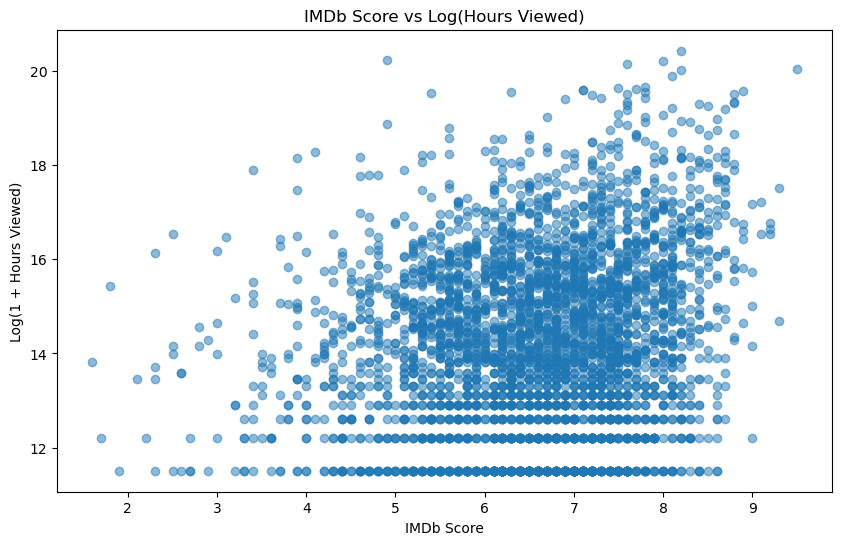

In [52]:
import matplotlib.pyplot as plt

# Scatterplot of IMDb score vs Hours_Viewed
# This explores whether higher-rated titles also tend to receive more watch time.
# Because Hours_Viewed is highly skewed, log1p is used on the y-axis
# to make the relationship easier to interpret.

plt.figure(figsize=(10, 6))
plt.scatter(final_df["imdb_score"], np.log1p(final_df["Hours_Viewed"]), alpha=0.5)

plt.title("IMDb Score vs Log(Hours Viewed)")
plt.xlabel("IMDb Score")
plt.ylabel("Log(1 + Hours Viewed)")

plt.show()

The scatterplot of **IMDb score** versus **log-transformed `Hours_Viewed`** suggests a generally positive relationship between audience ratings and watch time, but the pattern is not especially tight. Titles with higher IMDb scores often reach higher engagement levels, yet there is still substantial variation in `Hours_Viewed` at nearly every rating level. This suggests that stronger audience reception is associated with higher watch time, but ratings alone do not fully determine viewer engagement, implying that other content or market factors likely also influence performance.

## 6: scatterplot of imdb_votes vs Hours_Viewed

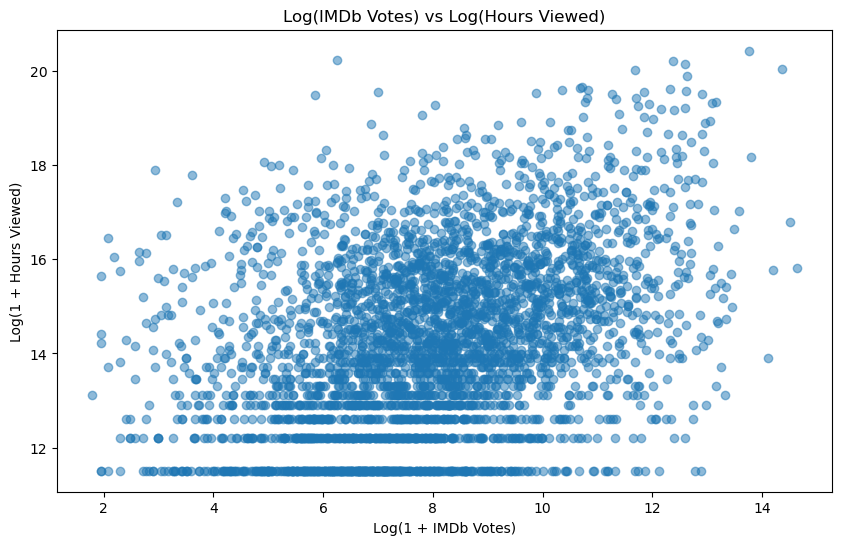

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Scatterplot of IMDb votes vs Hours_Viewed
# This explores whether titles with more audience attention on IMDb
# also tend to generate more watch time on Netflix.
# Both axes are log-transformed because the variables are highly skewed.

plt.figure(figsize=(10, 6))
plt.scatter(
    np.log1p(final_df["imdb_votes"]),
    np.log1p(final_df["Hours_Viewed"]),
    alpha=0.5
)

plt.title("Log(IMDb Votes) vs Log(Hours Viewed)")
plt.xlabel("Log(1 + IMDb Votes)")
plt.ylabel("Log(1 + Hours Viewed)")

plt.show()

The scatterplot of **log-transformed IMDb votes** versus **log-transformed `Hours_Viewed`** shows a clear positive relationship: titles with more IMDb voting activity generally also receive more watch time on Netflix. I used log transformations on both variables because each distribution is highly skewed, and the transformed scale makes the pattern easier to interpret. Compared with IMDb score, IMDb votes appear to have a stronger relationship with watch time, suggesting that broader title popularity and visibility may be more closely linked to viewer engagement than ratings alone.

## 7: line chart of Google Trends search interest over time.

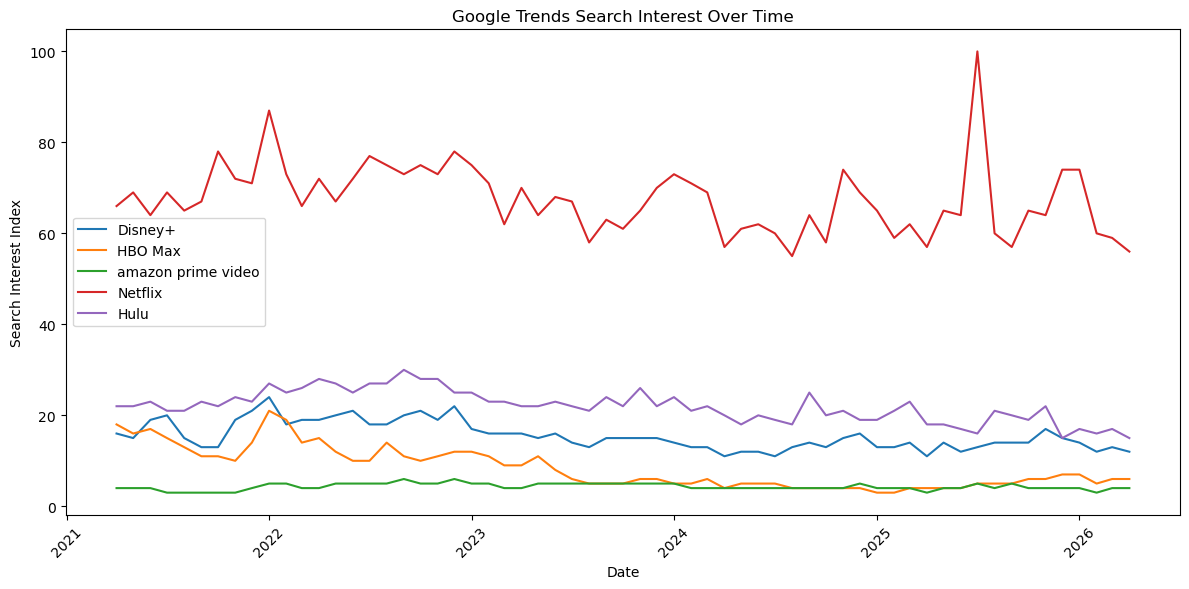

In [54]:
import matplotlib.pyplot as plt

# Convert the first column to datetime
# Replace the column name below with your actual date column name if needed.
trends_df.iloc[:, 0] = pd.to_datetime(trends_df.iloc[:, 0])

# Line chart of Google Trends search interest over time
# This compares public search interest for major streaming platforms.

plt.figure(figsize=(12, 6))

for col in trends_df.columns[1:]:
    plt.plot(trends_df.iloc[:, 0], trends_df[col], label=col)

plt.title("Google Trends Search Interest Over Time")
plt.xlabel("Date")
plt.ylabel("Search Interest Index")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Google Trends time-series chart shows that Netflix consistently has much higher search interest than the other streaming platforms included in the comparison. Although its search interest fluctuates over time and includes several spikes, Netflix remains clearly dominant in public attention throughout the period. This suggests that Netflix’s main challenge is likely not a lack of awareness, but rather how to turn strong market attention into sustained engagement, subscriber retention, and revenue growth.

## 8: top 10 titles by Hours_Viewed

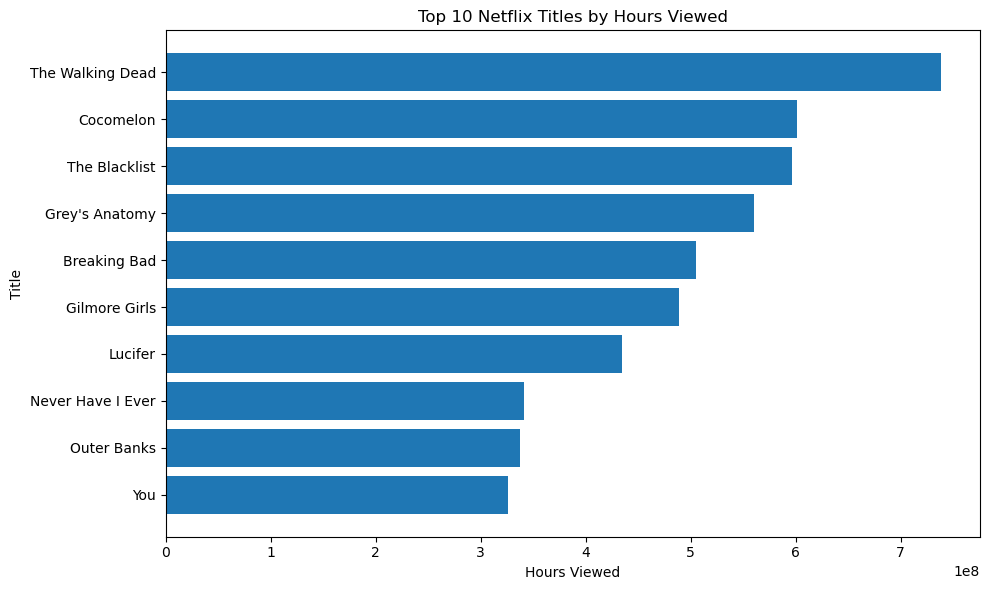

In [57]:
import matplotlib.pyplot as plt

# Top 10 titles by Hours_Viewed
# This highlights the titles with the strongest engagement in the matched dataset.

top_titles = (
    final_df[["title", "Hours_Viewed"]]
    .sort_values("Hours_Viewed", ascending=False)
    .head(10)
    .sort_values("Hours_Viewed", ascending=True)  # makes the bar chart easier to read
)

plt.figure(figsize=(10, 6))
plt.barh(top_titles["title"], top_titles["Hours_Viewed"])

plt.title("Top 10 Netflix Titles by Hours Viewed")
plt.xlabel("Hours Viewed")
plt.ylabel("Title")

plt.tight_layout()
plt.show()

The top-10 chart shows that a small number of titles generate exceptionally high watch-time totals, with **The Walking Dead** leading the matched dataset. This reinforces the earlier evidence that Netflix engagement is highly concentrated rather than evenly distributed across titles. From a business perspective, this suggests that a relatively limited set of breakout titles may drive a disproportionate share of overall viewer engagement, making high-performing content strategically important.

## 9: Average watch time by age certification

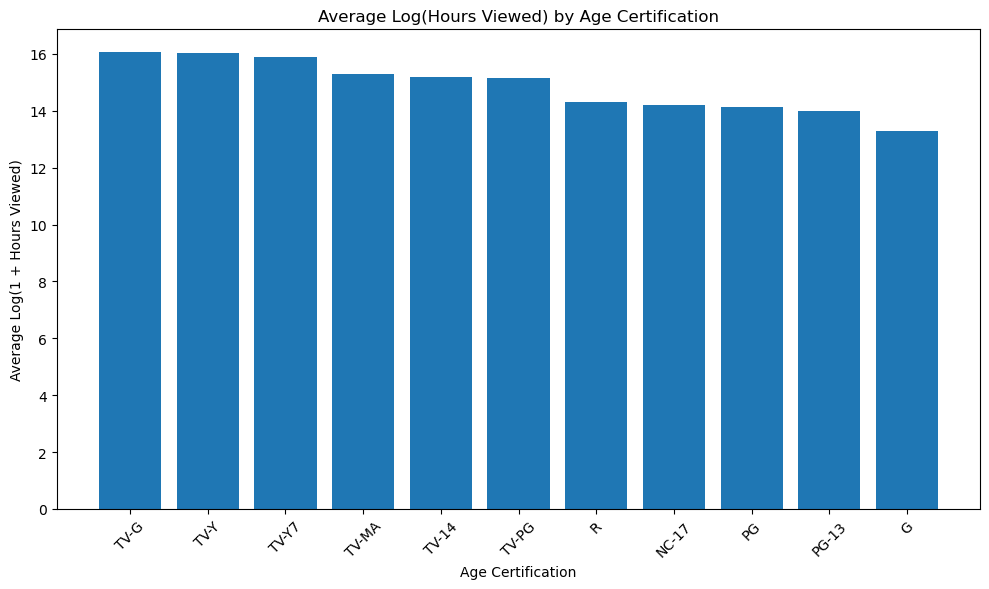

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Average log-transformed Hours_Viewed by age certification
# This shows whether titles aimed at different audience categories
# tend to have different engagement levels.

plot_df = final_df.copy()

# Keep only rows with non-missing age certification
plot_df = plot_df.dropna(subset=["age_certification"]).copy()

# Log-transform Hours_Viewed to reduce the effect of extreme outliers
plot_df["log_Hours_Viewed"] = np.log1p(plot_df["Hours_Viewed"])

# Compute average log watch time by age certification
age_hours = (
    plot_df.groupby("age_certification", as_index=False)["log_Hours_Viewed"]
    .mean()
    .sort_values("log_Hours_Viewed", ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(age_hours["age_certification"], age_hours["log_Hours_Viewed"])

plt.title("Average Log(Hours Viewed) by Age Certification")
plt.xlabel("Age Certification")
plt.ylabel("Average Log(1 + Hours Viewed)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart of **average log-transformed `Hours_Viewed` by age certification** shows that TV-oriented categories such as **TV-G, TV-Y, and TV-Y7** have the highest average watch-time levels in the matched dataset, while categories such as **G** and **PG-13** appear lower. I used a log transformation because raw watch-time values are highly skewed, and the transformed scale makes category comparisons more stable. This suggests that age-targeting may be associated with differences in engagement, which makes age certification a potentially useful variable for Netflix’s content-strategy decisions.